In [1]:
import pandas as pd
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Notice the '../' added here to step out of the notebooks folder
df = pd.read_csv('../data/processed/clean_data.csv')

# Initialize VADER
sia = SentimentIntensityAnalyzer()

# Scoring function
def vader_predict(text):
    score = sia.polarity_scores(str(text))['compound']
    return 1 if score >= 0.05 else 0

# Apply predictions
df['vader_pred'] = df['clean_text'].apply(vader_predict)

# Evaluate results
print('VADER Accuracy:', accuracy_score(df['sentiment'], df['vader_pred']))
print(classification_report(df['sentiment'], df['vader_pred'], target_names=['Negative', 'Positive']))

VADER Accuracy: 0.64157
              precision    recall  f1-score   support

    Negative       0.64      0.66      0.65     50000
    Positive       0.65      0.62      0.63     50000

    accuracy                           0.64    100000
   macro avg       0.64      0.64      0.64    100000
weighted avg       0.64      0.64      0.64    100000



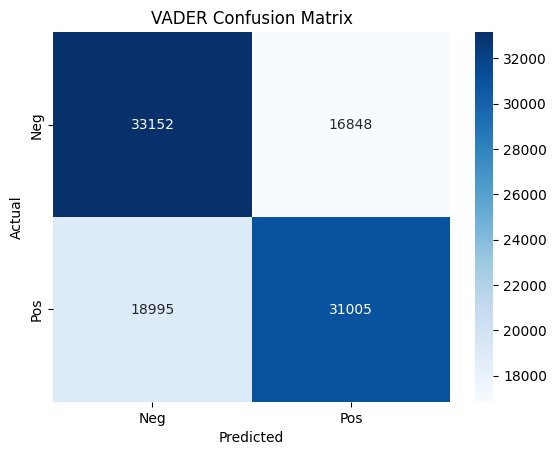

In [2]:
##PLOT THE VADER CONFUSION MATRIX

# Generate matrix
cm = confusion_matrix(df['sentiment'], df['vader_pred'])

# Plotting setup
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
plt.title('VADER Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')

# Notice the '../' added here to save right into your existing reports folder
plt.savefig('../reports/05_vader_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
